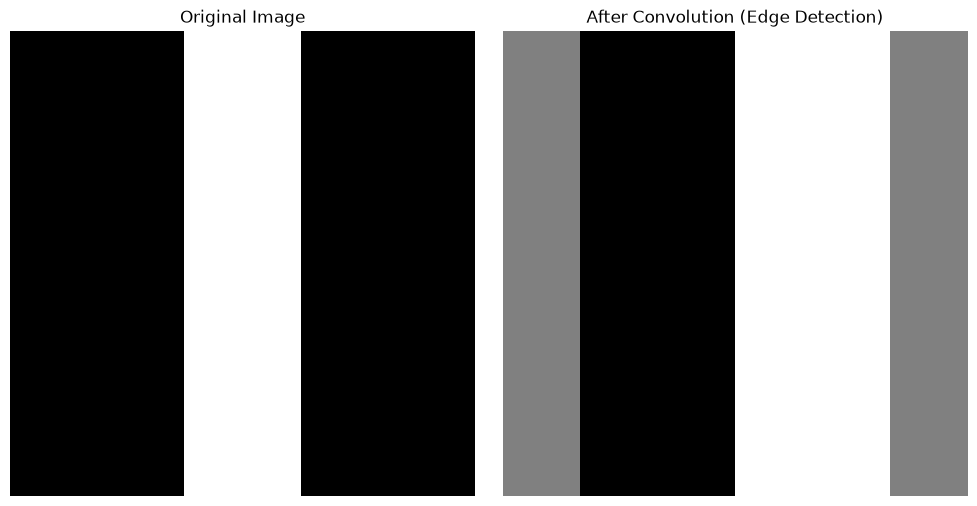

In [12]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

filter_2d = torch.tensor([[
    [1.0, 0.0, -1.0],
    [1.0, 0.0, -1.0],
    [1.0, 0.0, -1.0]
]]).unsqueeze(0)

sample_image_2 = torch.zeros(1, 1, 8, 8)
sample_image_2[0, 0, :, 3:5] = 1.0

output_2 = nn.functional.conv2d(sample_image_2, filter_2d)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_image_2[0, 0].numpy(), cmap='gray')
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(output_2[0, 0].detach().numpy(), cmap='gray')
plt.title('After Convolution (Edge Detection)')
plt.axis('off')
plt.tight_layout()
plt.show()

In [13]:
import torch.nn.functional as F
input_image = torch.randn(1, 1, 6, 6)
filter = torch.randn(1, 1, 3, 3)

output1 = F.conv2d(input_image, filter, stride=1, padding=0)
print(f"Valid 패딩 출력 크기: {output1.shape}")

output2 = F.conv2d(input_image, filter, stride=1, padding=1)
print(f"Same 패딩 출력 크기: {output2.shape}")

output3 = F.conv2d(input_image, filter, stride=2, padding=0)
print(f"스트라이드=2 출력 크기: {output3.shape}")

Valid 패딩 출력 크기: torch.Size([1, 1, 4, 4])
Same 패딩 출력 크기: torch.Size([1, 1, 6, 6])
스트라이드=2 출력 크기: torch.Size([1, 1, 2, 2])


In [15]:
input_rgb = torch.randn(1, 3, 32, 32)
filters = torch.randn(16, 3, 3, 3)

output_feature_maps = F.conv2d(input_rgb, filters, stride=1, padding=1)
print(f"출력 특성 맵 크기: {output_feature_maps.shape}")

출력 특성 맵 크기: torch.Size([1, 16, 32, 32])


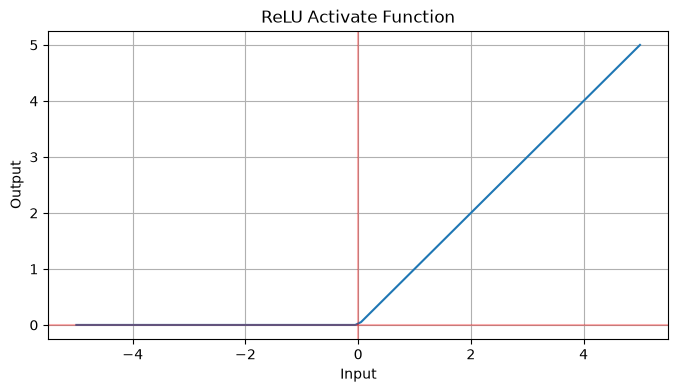

In [18]:
relu = nn.ReLU()
x = torch.linspace(-5, 5, 100)
y = relu(x)

plt.figure(figsize=(8, 4))
plt.plot(x.numpy(), y.numpy())
plt.grid(True)
plt.title('ReLU Activate Function')
plt.xlabel('Input')
plt.ylabel('Output')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='r', linestyle='-', alpha=0.3)
plt.show()

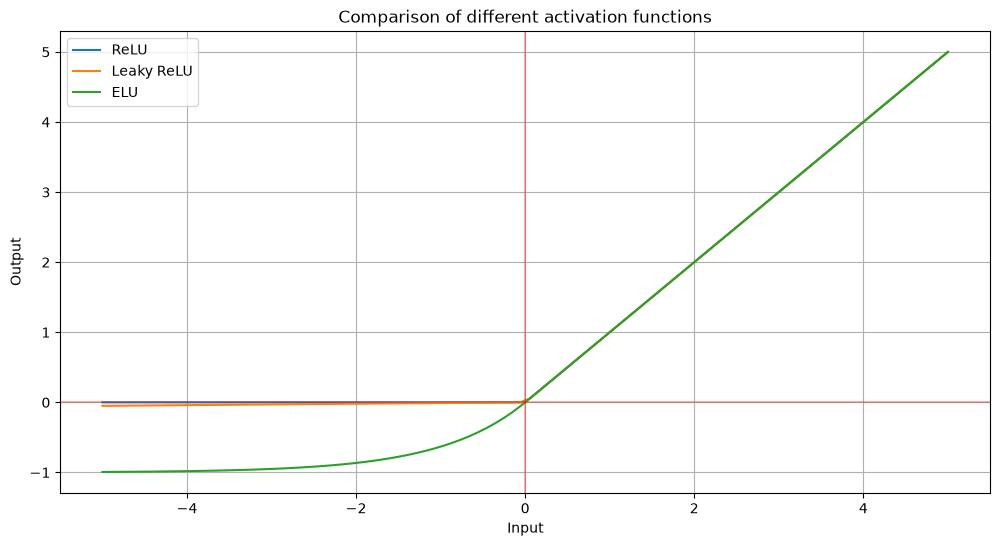

In [22]:
#다양한 활성화 함수 비교
x = torch.linspace(-5, 5, 100)
relu = F.relu(x)
leaky_relu = F.leaky_relu(x, 0.01)
elu = F.elu(x)

plt.figure(figsize=(12, 6))
plt.plot(x.numpy(), relu.numpy(), label='ReLU')
plt.plot(x.numpy(), leaky_relu.numpy(), label='Leaky ReLU')
plt.plot(x.numpy(), elu.numpy(), label='ELU')
plt.grid(True)
plt.legend()
plt.title('Comparison of different activation functions')
plt.xlabel('Input')
plt.ylabel('Output')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='r', linestyle='-', alpha=0.3)
plt.show()

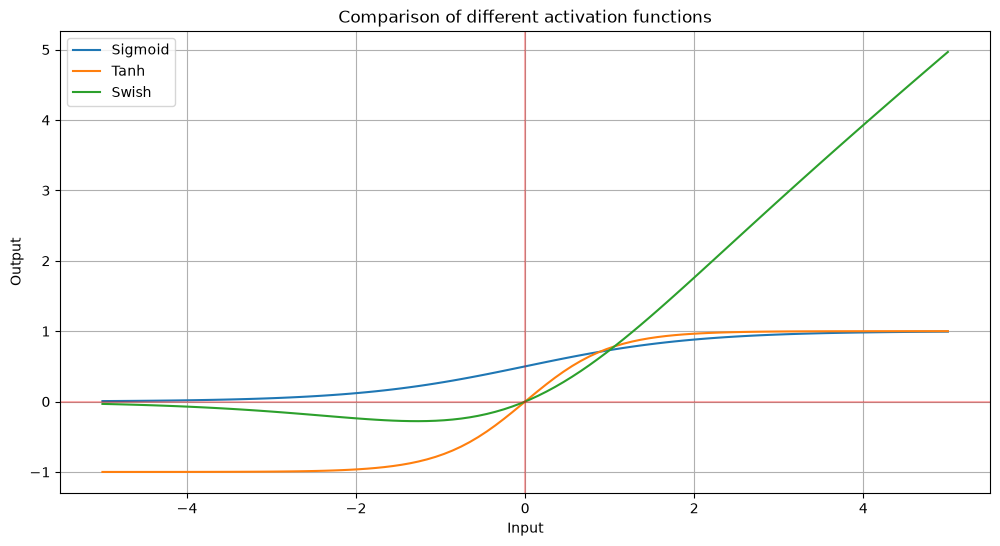

In [ ]:
#다양한 활성화 함수 비교
x = torch.linspace(-5, 5, 100)
sigmoid = torch.sigmoid(x)
tanh = torch.tanh(x)
swish = x * torch.sigmoid(x)

plt.figure(figsize=(12, 6))
plt.plot(x.numpy(), sigmoid.numpy(), label='Sigmoid')
plt.plot(x.numpy(), tanh.numpy(), label='Tanh')
plt.plot(x.numpy(), swish.numpy(), label='Swish')
plt.grid(True)
plt.legend()
plt.title('Comparison of different activation functions')
plt.xlabel('Input')
plt.ylabel('Output')
plt.axhline(y=0, color='r', linestyle='-', alpha=0.3)
plt.axvline(x=0, color='r', linestyle='-', alpha=0.3)
plt.show()

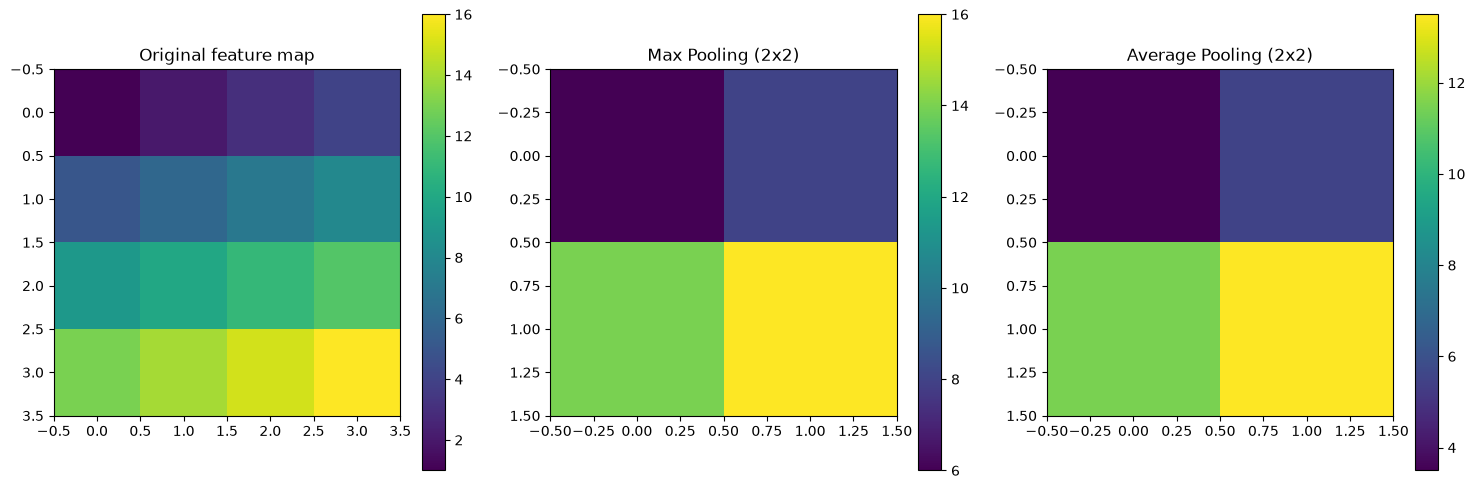

In [24]:
# 최대 풀링과 평균 풀링 비교
feature_map = torch.tensor([[
    [1.0, 2.0, 3.0, 4.0],
    [5.0, 6.0, 7.0, 8.0],
    [9.0, 10.0, 11.0, 12.0],
    [13.0, 14.0, 15.0, 16.0],
]]).unsqueeze(0)

max_pooled = F.max_pool2d(feature_map, kernel_size=2, stride=2)
avg_pooled = F.avg_pool2d(feature_map, kernel_size=2, stride=2)

plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(feature_map[0, 0].numpy(), cmap='viridis')
plt.title('Original feature map')
plt.colorbar()
plt.subplot(1, 3, 2)
plt.imshow(max_pooled[0, 0].numpy(), cmap='viridis')
plt.title('Max Pooling (2x2)')
plt.colorbar()
plt.subplot(1, 3, 3)
plt.imshow(avg_pooled[0, 0].numpy(), cmap='viridis')
plt.title('Average Pooling (2x2)')
plt.colorbar()
plt.tight_layout()
plt.show()

In [26]:
import torch
import torch.nn as nn

# 샘플 특성 맵 (배치 크기 1, 채널 3, 높이 4, 너비 4)
feature_maps = torch.randn(1, 3, 4, 4)

# 전역 평균 풀링 적용
global_avg_pool = nn.AdaptiveAvgPool2d((1, 1))
output = global_avg_pool(feature_maps)
print(f"원본 특성 맵 크기: {feature_maps.shape}")
print(f"전역 평균 풀링 후 크기: {output.shape}")
print(f"평탄화 후 크기: {output.view(1, -1).shape}")

원본 특성 맵 크기: torch.Size([1, 3, 4, 4])
전역 평균 풀링 후 크기: torch.Size([1, 3, 1, 1])
평탄화 후 크기: torch.Size([1, 3])
